### Quantum Fourier Transform
with Qiskit

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFTGate

In [2]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService
 
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler
 
service = QiskitRuntimeService()
 
# Use the least busy backend
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
 
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2025-11-22 12:49:50,158: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: eloza. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-22 12:49:50,842: Loading instance: eloza, plan: open
qiskit_runtime_service.backends:WARNING:2025-11-22 12:49:53,593: Using instance: eloza, plan: open


ibm_torino


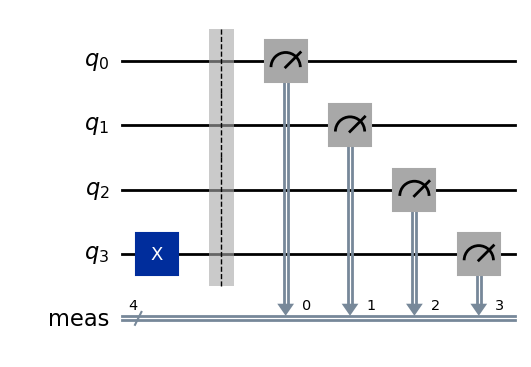

In [3]:
# Step 1: Map
 
qubits = 4
N = 2**qubits
 
 
qc = QuantumCircuit(qubits)
 
# flip state of random qubits to put in a random single computational basis state
for i in range(1, qubits):
    if np.random.randint(0, 2):
        qc.x(i)
 
 
# make a copy of the above circuit. (to be used when we apply the QFT in next part)
qc_qft = qc.copy()
 
 
qc.measure_all()
qc.draw("mpl")

In [5]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc)
 
# Step 3: Run the job on a real quantum computer OR try fake backend
 
sampler = Sampler(mode=backend)
pubs = [qc_isa]
 
# Run the job on real quantum device
 
job = sampler.run(pubs, shots=1000)
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d4gq7k12bisc73a3q3l0


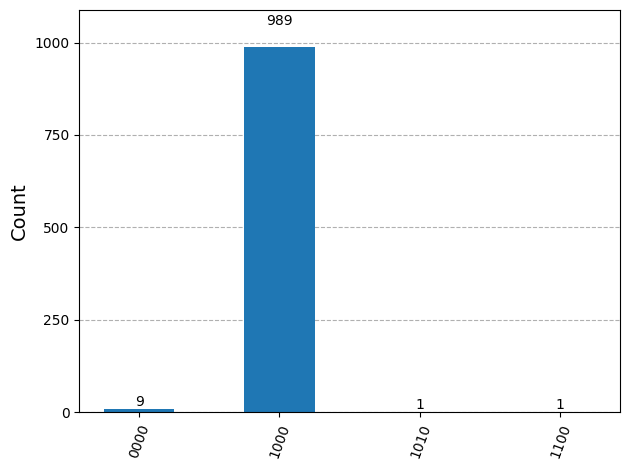

In [6]:
# postprocessing and visualization
res = service.job(job_id).result()
counts = res[0].data.meas.get_counts()
 
# Step 4: Post-Process
plot_histogram(counts)

#### Now, let's Fourier transform this state with QFTGate:

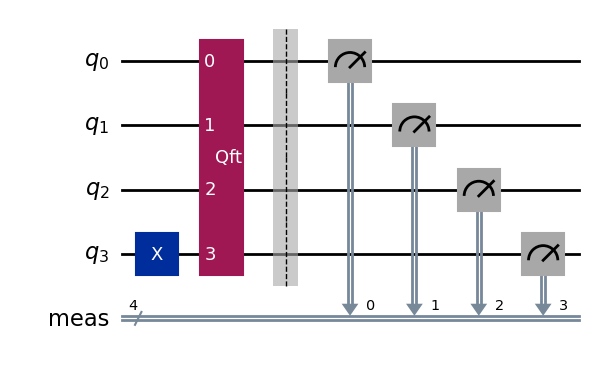

In [7]:
# Step 1: Map
 
qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.measure_all()
qc_qft.draw("mpl")

In [8]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc_qft)
 
# Step 3: Run the job on a real quantum computer - try fake backend
 
sampler = Sampler(mode=backend)
pubs = [qc_isa]
 
# Run the job on real quantum device
 
job = sampler.run(pubs, shots=1000)
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d4gq8golslhc73d1004g


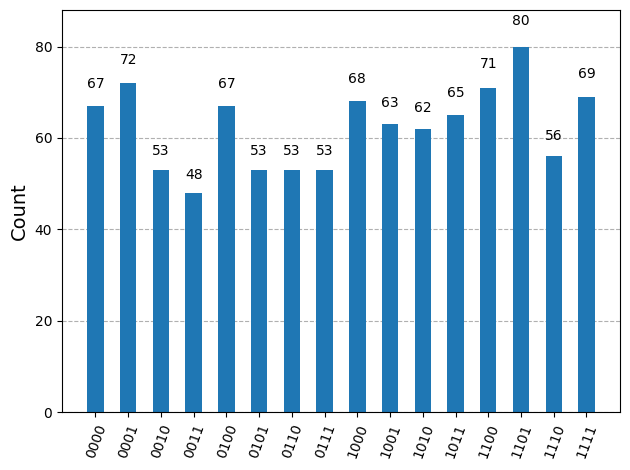

In [9]:
res = service.job(job_id).result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
plot_histogram(counts)

#### Two computational basis states

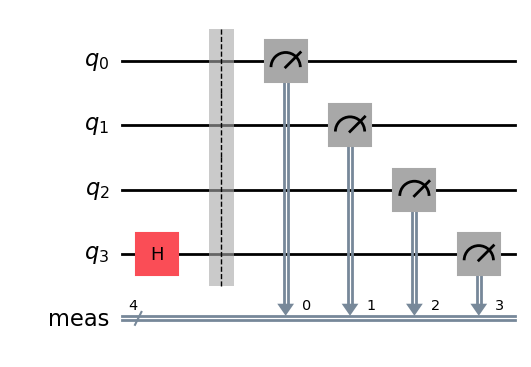

In [10]:
# Step 1: Map
qubits = 4
N = 2**qubits
 
 
qc = QuantumCircuit(qubits)
 
# To make this state, we just need to apply a Hadamard to the last qubit
 
qc.h(qubits - 1)
 
 
qc_qft = qc.copy()
 
 
qc.measure_all()
 
qc.draw("mpl")

In [11]:
# First, let's go through steps 2-4 for the first circuit, qc
 
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc)
 
# Step 3: Run the job on a real quantum computer - try fake backend
 
sampler = Sampler(mode=backend)
pubs = [qc_isa]
 
# Run the job on real quantum device
 
job = sampler.run(pubs, shots=1000)
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d4gq9m6lo8as739q0ms0


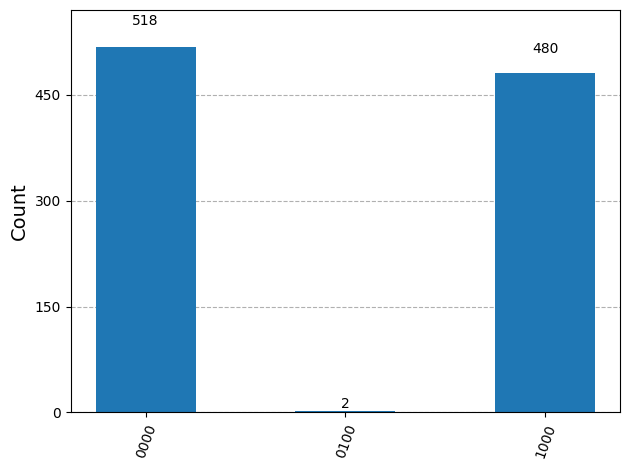

In [12]:
res = service.job(job_id).result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-process
plot_histogram(counts)

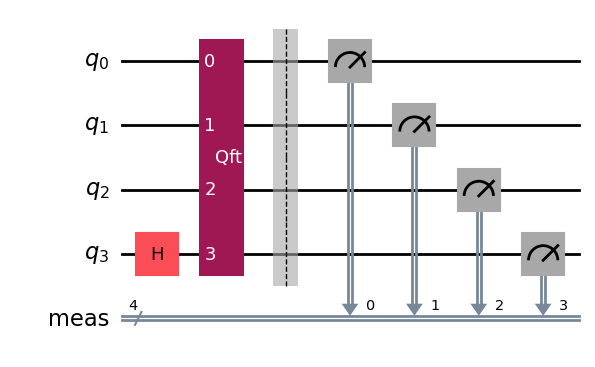

In [13]:
# now we Fourier transform this state with QFTGate:
# Step 1: Map
 
qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.measure_all()
qc_qft.draw("mpl")

In [14]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc_qft)
 
# Step 3: Run the job on a real quantum computer OR try fake backend
 
sampler = Sampler(mode=backend)
pubs = [qc_isa]
 
# Run the job on real quantum device
 
job = sampler.run(pubs, shots=1000)
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d4gqa7olslhc73d101p0


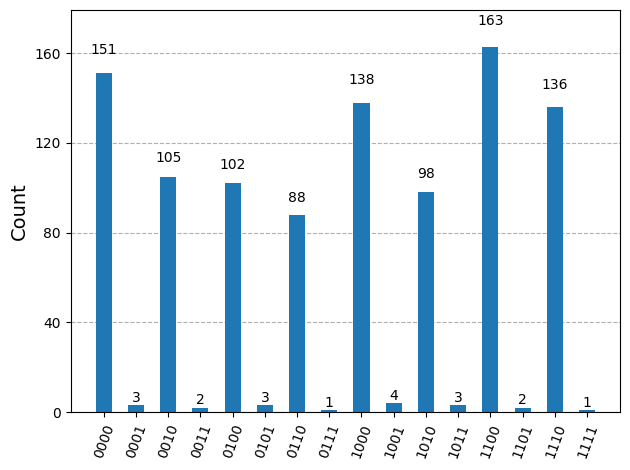

In [15]:
res = service.job(job_id).result()
counts = res[0].data.meas.get_counts()

# Step 4: Post-process
plot_histogram(counts)